In [1]:
import numpy as np
import pandas as pd
import sys, os
import matplotlib.pyplot as plt

sys.path.append('../')
from fingerprint_analysis.calc_fps_rm import *
sys.path.append('../../')
from data_utils_local.data_utils_smiles import *
from data_utils_local.Generalised_data_utils import *

%load_ext autoreload
%autoreload 2

ModuleNotFoundError: No module named 'orderedset'

#### **Ablation study over Latent Space**

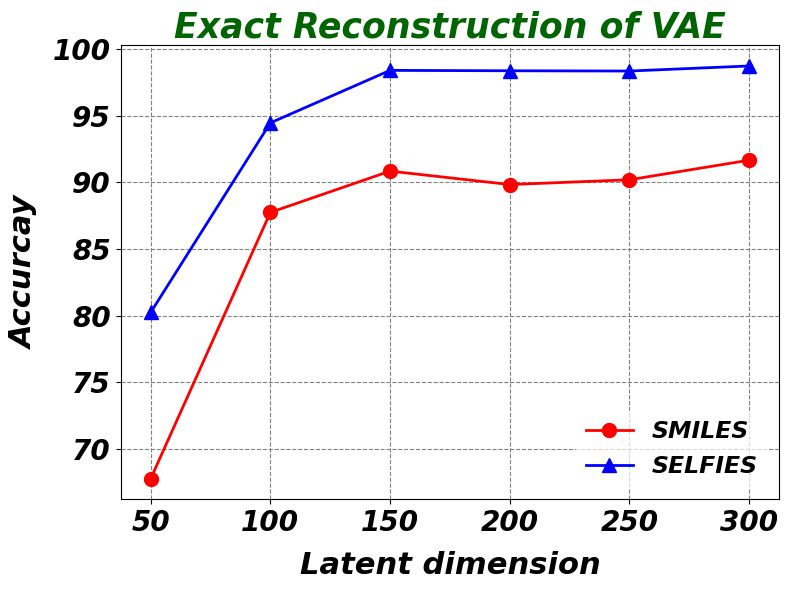

In [2]:
%matplotlib inline

dims = [50, 100, 150, 200, 250, 300]
vae_smi_exact = [67.76, 87.75, 90.85, 89.84, 90.20, 91.67]
svae_smi_exact = [67.76, 87.75, 90.85, 94.04, 93.20, 94.60]
vae_slfi_exact = [80.24, 94.47, 98.41, 98.38, 98.36, 98.74]

X = np.array([dims, vae_smi_exact]).T
Y = np.array([dims, vae_slfi_exact]).T

## Increase the figure size to get the original figure. It is willingly decreased to reduce memory.
plot_2d(matrices=[X, Y], 
        plot_type='line',
        title = 'Exact Reconstruction of VAE',
        scatter_labels = ['SMILES', 'SELFIES'],
        fig_size=(8, 6),
        x_label='Latent dimension',
        y_label='Accurcay',
        # title_fontsize=2,
        # linewidth=0.5,
        )


In [3]:
names_list = ['fp', 'bert', 'evsmi', 'hvsmi', 'evslfi']
names_dict = {'fp':'Morgan_FP', 'bert':'Chemberta-2', 'evsmi': 'VAE + SMILES', 'hvsmi': fr'S-VAE + SMILES', 'evslfi':'VAE + SELFIES'}
path_init = '/home/rkmvu/Codes/ICDCIT_submission/results/drug_props_with_embeds_{NAME}.csv'

dfs_dict = {}
latent_dict = {}
props_dict = {}
for name in names_list:
    path_temp = path_init.format(NAME=name)
    _df = pd.read_csv(path_temp)
    dfs_dict['name'] = _df
    z = _df[[x for x in _df.columns if 'dim' in x]]
    props = _df[[x for x in _df.columns if 'dim' not in x]]

    latent_dict[name] = z.values
    props_dict[name] = props

In [4]:
from tqdm import tqdm

df_ = latent_dict['fp']
matrix = np.zeros((len(df_), len(df_)))

for i in tqdm(range(len(df_))):
    for j in range(len(df_)):
        if i<j:
            fp1 = df_[i]
            fp2 = df_[j]
            a, b, c, d = get_abcd(array_1=fp1, array_2=fp2)
            sim, dis = compute_similarity_distance_metrics(a, b, c, d)

            matrix[i, j] = sim['Tanimoto']

matrix

  0%|          | 4/1089 [00:00<01:18, 13.77it/s]

100%|██████████| 1089/1089 [00:30<00:00, 36.19it/s] 


array([[0.        , 0.1       , 0.046875  , ..., 0.09210526, 0.07352941,
        0.10126582],
       [0.        , 0.        , 0.10144928, ..., 0.10843373, 0.10810811,
        0.09090909],
       [0.        , 0.        , 0.        , ..., 0.09090909, 0.08695652,
        0.03225806],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.1       ,
        0.08108108],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.09375   ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [5]:
# def mat2vec(matrix):
#     array = []
#     for i in range(matrix.shape[0]):
#         for j in range(matrix.shape[0]):
#             if i<j:
#                array.append(matrix[i, j]) 
#     return np.array(array)

In [6]:
latent_dict['evslfi'].shape

(1089, 300)

#### **Calculating the correlations between the similarities in embedding space**

In [15]:
# props_dict[name] #LogP, NumHAcceptor
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr, pearsonr, kendalltau

matrix_vec = matrix[np.triu_indices_from(matrix, k=1)]
all_pairwise_dist = {'fp':matrix_vec}

for name in names_list:
    dist = cosine_similarity(latent_dict[name])
    dist_vec = dist[np.triu_indices_from(dist, k=1)]
    all_pairwise_dist[name] = dist_vec
    spr, _ = spearmanr(dist_vec, matrix_vec)
    prs, _ = pearsonr(dist_vec, matrix_vec)
    kdt, _ = kendalltau(dist_vec, matrix_vec)
    print(name, spr, prs, kdt)

fp 0.9920097633367501 0.9850733153446422 0.9394565230872247
bert 0.5473575680420183 0.47177457619452123 0.3825333048179086
evsmi 0.1929069036790801 0.2298335254953739 0.13121775955970622
hvsmi 0.19317208973825145 0.21216147858251833 0.13048597470508477
evslfi 0.14189234154019836 0.18187113318013393 0.0964515121823655


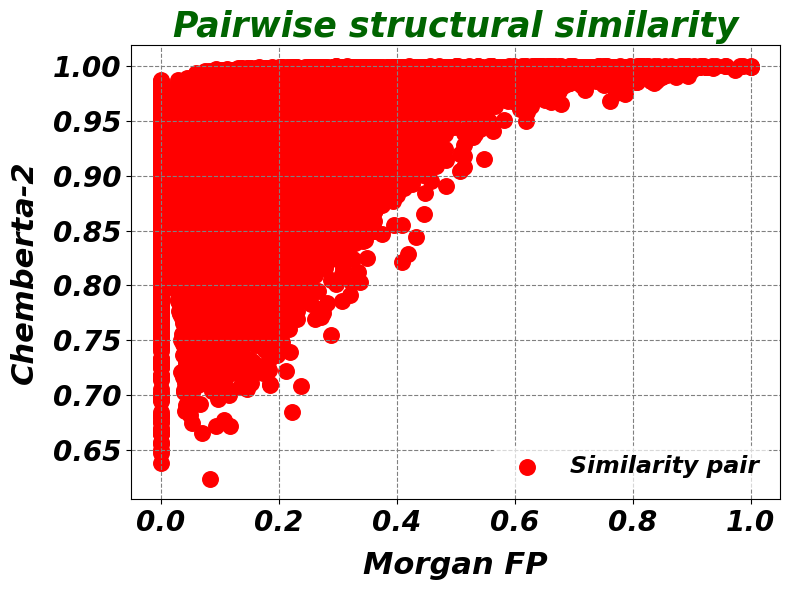

In [28]:
# props_dict[name].columns
matrices = {name:np.array([all_pairwise_dist['fp'].tolist(), all_pairwise_dist[name].tolist()]).T for name in names_list}
matrices.pop('fp')
matrices

for name in names_list:
    if name != 'fp':
        plot_2d(matrices=[matrices[name]], 
                plot_type='scatter',
                title = 'Pairwise structural similarity',
                scatter_labels = [f'Similarity pair'],
                fig_size=(8, 6),
                x_label='Morgan FP',
                y_label=names_dict[name],
                # title_fontsize=2,
                # linewidth=0.5,
                )
        break

#### **Calculating the correlations between the distances in embedding space w.r.t molecular descriptors**

In [9]:
from sklearn.metrics import pairwise_distances
from scipy.stats import spearmanr, pearsonr, kendalltau
import warnings
warnings.filterwarnings('ignore')

prop_list = ['LogP', 'Molecular Mass', 'NumHDonors', 'NumHAcceptor', 'TPSA', 'NumRotatableBonds']
print('-'*80)
for name in names_list:
    print(f'Name: {name}')
    print('-'*30)
    for prop in prop_list:
        if name == 'fp':
            embed_dist = pairwise_distances(latent_dict[name], metric='jaccard')
            embed_dist = pairwise_distances(latent_dict[name])
        # elif name == 'hvsmi':
        #     embed_dist = pairwise_distances(latent_dict[name], metric='cosine')
        else:
            embed_dist = pairwise_distances(latent_dict[name])
        prop_dist = pairwise_distances(props_dict[name][prop].values.reshape(-1, 1))
        embed_dist_vec = embed_dist[np.triu_indices_from(embed_dist, k=1)]
        prop_dist_vec = prop_dist[np.triu_indices_from(prop_dist, k=1)]
        spr_prop, _ = spearmanr(embed_dist_vec, prop_dist_vec)
        prs_prop, _ = pearsonr(embed_dist_vec, prop_dist_vec)
        kdt_prop, _ = kendalltau(embed_dist_vec, prop_dist_vec)
        print(prop, round(spr_prop, 2))
    print('-'*80)
    

--------------------------------------------------------------------------------
Name: fp
------------------------------


LogP 0.11
Molecular Mass 0.32
NumHDonors 0.21
NumHAcceptor 0.38
TPSA 0.32
NumRotatableBonds 0.21
--------------------------------------------------------------------------------
Name: bert
------------------------------
LogP 0.17
Molecular Mass 0.18
NumHDonors 0.1
NumHAcceptor 0.13
TPSA 0.17
NumRotatableBonds 0.05
--------------------------------------------------------------------------------
Name: evsmi
------------------------------
LogP 0.2
Molecular Mass 0.58
NumHDonors 0.26
NumHAcceptor 0.45
TPSA 0.4
NumRotatableBonds 0.3
--------------------------------------------------------------------------------
Name: hvsmi
------------------------------
LogP 0.12
Molecular Mass 0.7
NumHDonors 0.17
NumHAcceptor 0.38
TPSA 0.3
NumRotatableBonds 0.18
--------------------------------------------------------------------------------
Name: evslfi
------------------------------
LogP 0.21
Molecular Mass 0.6
NumHDonors 0.27
NumHAcceptor 0.48
TPSA 0.4
NumRotatableBonds 0.25
---------------------------

#### **Calculating the Correlation between the pairwise distances of all the embedding methods**

In [ ]:
from sklearn.metrics import pairwise_distances
from scipy.stats import spearmanr, pearsonr, kendalltau
import warnings
warnings.filterwarnings('ignore')

print('-'*80)
for name1 in names_list:
    for name2 in names_list:
        print(f'Name: {name1}, {name2}')
        print('-'*30)
        if name1 == 'fp':
            embed_dist1 = pairwise_distances(latent_dict[name1], metric='jaccard')
        else:
            embed_dist1 = pairwise_distances(latent_dict[name1])

        if name2 == 'fp':
            embed_dist2 = pairwise_distances(latent_dict[name2], metric='jaccard')
        else:
            embed_dist2 = pairwise_distances(latent_dict[name2])

        embed_dist_vec1 = embed_dist1[np.triu_indices_from(embed_dist1, k=1)]
        embed_dist_vec2 = embed_dist2[np.triu_indices_from(embed_dist2, k=1)]
        
        spr_prop, _ = spearmanr(embed_dist_vec1, embed_dist_vec2)
        prs_prop, _ = pearsonr(embed_dist_vec1, embed_dist_vec2)
        kdt_prop, _ = kendalltau(embed_dist_vec1, embed_dist_vec2)
        print(round(spr_prop, 2))
    print('-'*80)
    

--------------------------------------------------------------------------------
Name: fp, fp
------------------------------


1.0
Name: fp, bert
------------------------------
0.54
Name: fp, evsmi
------------------------------
0.1
Name: fp, hvsmi
------------------------------
0.19
Name: fp, evslfi
------------------------------
0.08
--------------------------------------------------------------------------------
Name: bert, fp
------------------------------
0.54
Name: bert, bert
------------------------------
1.0
Name: bert, evsmi
------------------------------
0.15
Name: bert, hvsmi
------------------------------
0.23
Name: bert, evslfi
------------------------------
0.07
--------------------------------------------------------------------------------
Name: evsmi, fp
------------------------------
0.1
Name: evsmi, bert
------------------------------
0.15
Name: evsmi, evsmi
------------------------------
1.0
Name: evsmi, hvsmi
------------------------------
0.62
Name: evsmi, evslfi
------------------------------
0.89
--------------------------------------------------------------------------------
Name: hvsm

In [23]:
from umap.umap_ import UMAP
from sklearn.manifold import MDS, TSNE, Isomap
from sklearn.decomposition import PCA, KernelPCA, FactorAnalysis, TruncatedSVD
from sklearn.preprocessing import StandardScaler

names_dict = {'fp':'Morgan_FP', 'evslfi':'VAE + SELFIES', 'evsmi': 'VAE + SMILES', 'hvsmi': 'S-VAE + SMILES', 'bert':'Chemberta-2'}
name = 'evsmi' #, "UMAP"
prop_name = 'Molecular Mass'#'Molecular Mass'#'TPSA'#'LogP'#'NumHDonors'#'NumRotatableBonds'#'NumHAcceptor'
matrices= [latent_dict[k] for k in names_dict.keys()]#list(latent_dict.values())
labels = [props_dict[k][prop_name].values for k in names_dict.keys()]
rep_names = list(names_dict.values())
# id = 0

# reducers = {
#             "PCA": PCA(n_components=2, random_state=42),
#             "UMAP": UMAP(n_neighbors=10, min_dist=1., n_components=2, metric="cosine", random_state=42),
#             "Isomap": Isomap(n_components=2),
#             "FactorAnalysis": FactorAnalysis(n_components=2, random_state=42),
#             "MDS": MDS(n_components=2, random_state=42, n_init=1, max_iter=300),
#             "t-SNE": TSNE(n_components=2, random_state=42, init="pca"),
#             "TruncatedSVD": TruncatedSVD(n_components=2, random_state=42),
#             "KernelPCA": KernelPCA(n_components=2, kernel="rbf", random_state=42),
#         }
# X = StandardScaler().fit_transform(matrices[id])
# Z = reducers['UMAP'].fit_transform(X)


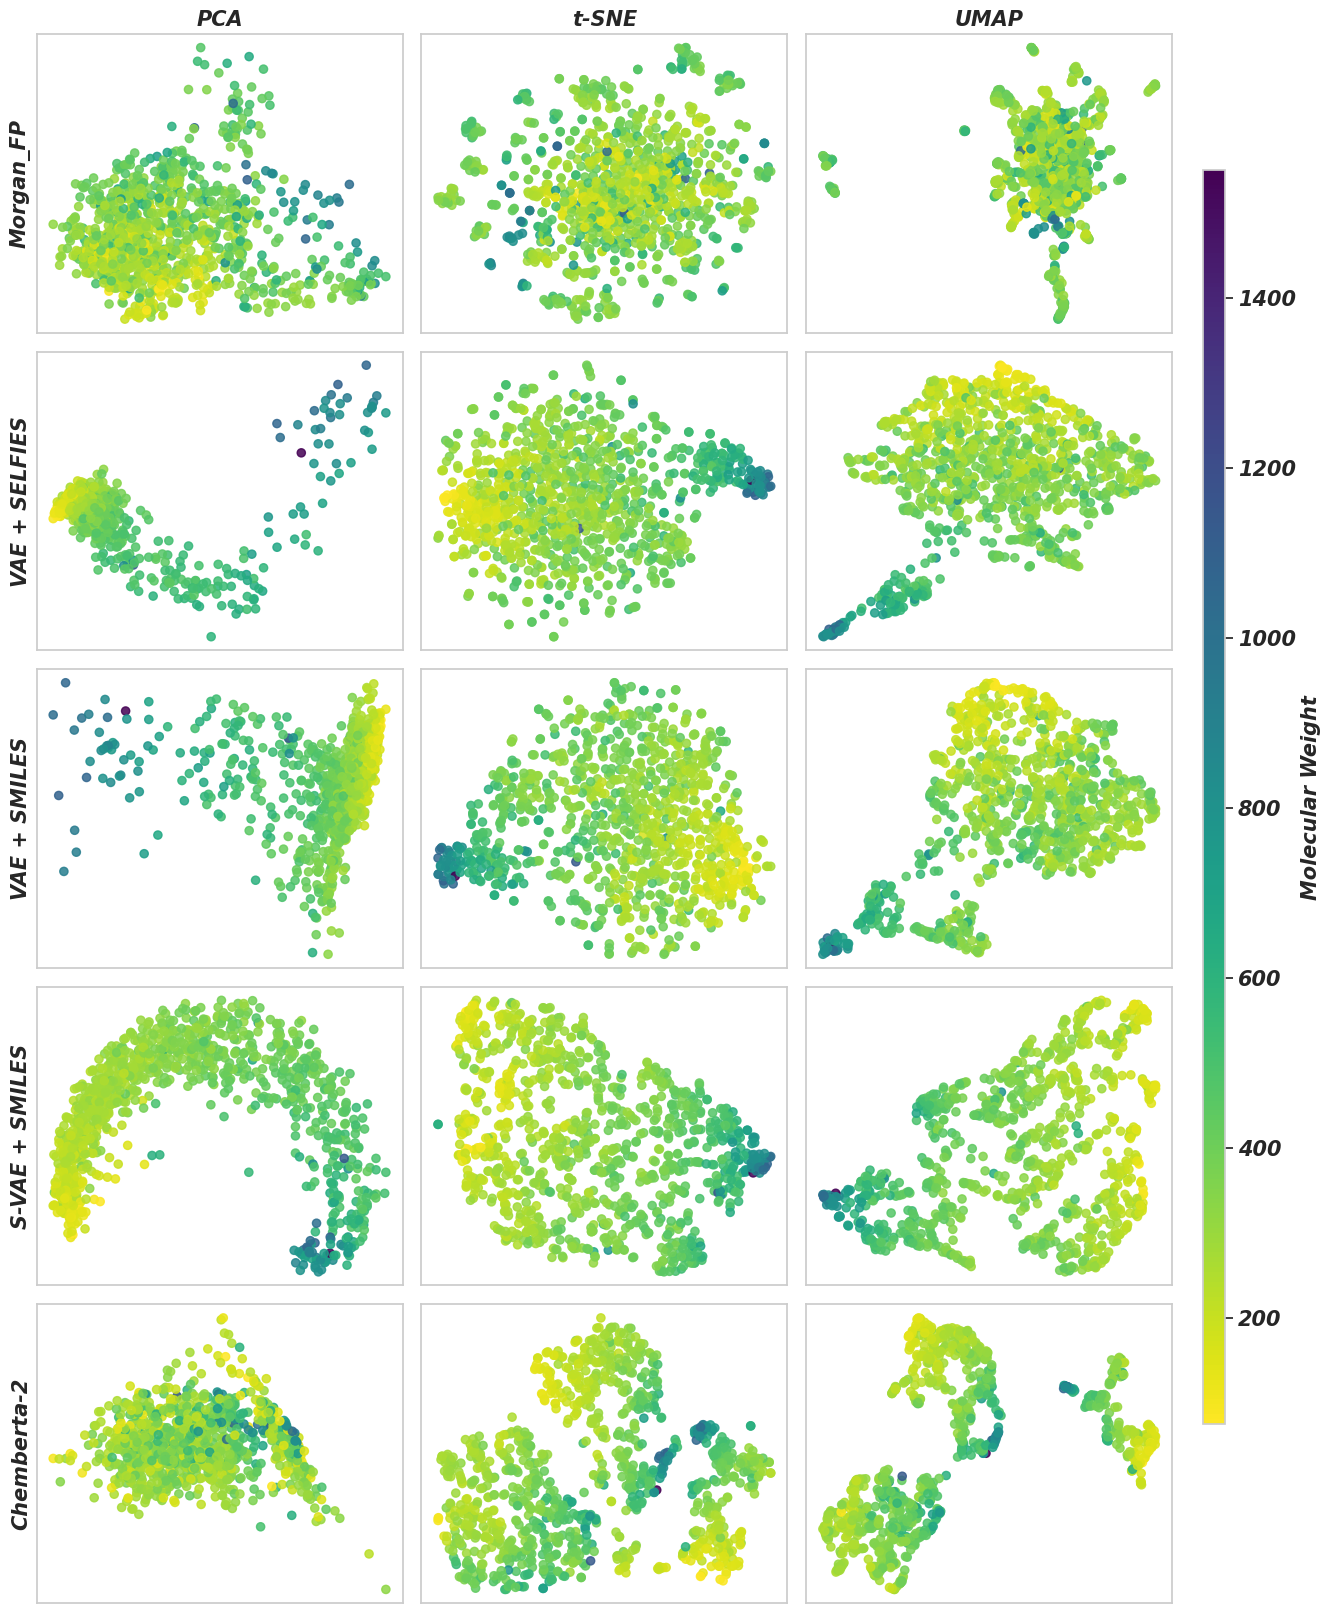

In [24]:
%matplotlib inline

plot_projection_grid_seaborn(matrices= matrices,
                            labels = labels,
                            rep_names = rep_names,
                            highlight_index=None,
                            cmap='viridis_r',
                            normalise=False,
                            show_xticks = False,
                            show_yticks = False,
                            suptitle = "",
                            # figsize=(15, 8),
                            # proj_names = ["PCA", "t-SNE", "UMAP", "Isomap", "FactorAnalysis", "MDS", "TruncatedSVD", "KernelPCA"],
                            proj_names = ["PCA", "t-SNE", "UMAP"],
                            cbar_label = prop_name if not prop_name=='Molecular Mass' else 'Molecular Weight',
                            show_grid=True,
                            # savepath=f'./projection_{prop_name.replace(' ', '_')}'
                            )

In [ ]:
%matplotlib inline

for id in range(len(labels)):
    plot_projection_grid_seaborn(matrices= matrices[id:id+1],
                                labels = labels[id:id+1],
                                rep_names = rep_names[id:id+1],
                                highlight_index=None,
                                cmap='viridis',
                                normalise=False,
                                show_xticks = False,
                                show_yticks = False,
                                suptitle = "",
                                # figsize=(15, 8),
                                # proj_names = ["PCA", "t-SNE", "UMAP", "Isomap", "FactorAnalysis", "MDS", "TruncatedSVD", "KernelPCA"],
                                proj_names = ["t-SNE"],
                                cbar_label = prop_name,
                                show_grid=True
                                )

In [53]:
from sklearn.svm import NuSVR, SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


repr_method = 'fp'
prop_name = 'LogP' #'Molecular Mass', 'LogP', 'Molar Refractivity', 'qed', 'TPSA', 'NumHDonors', 'NumHAcceptor', 'NumRotatableBonds', 'MolLogP'
prop_list = ['Molecular Mass', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptor', 'NumRotatableBonds']

for prop_name in prop_list:

    for repr_method in names_list:

        X = latent_dict[repr_method]
        y = props_dict[repr_method][prop_name]
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)

        lr_model = make_pipeline(StandardScaler(), LinearRegression())
        rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
        svm_model = make_pipeline(StandardScaler(), SVR())

        lr_model.fit(X_train, y_train)
        rf_model.fit(X_train, y_train)
        svm_model.fit(X_train, y_train)

        y_pred_lr = lr_model.predict(X_test)
        y_pred_rf = rf_model.predict(X_test)
        y_pred_svm = svm_model.predict(X_test)

        print(f"Configuration: {names_dict[repr_method]} + {prop_name}")
        print("-" * 80)
        print(f"R² Score LR : {r2_score(y_test, y_pred_lr):.4f}")
        print(f"RMSE LR:     {root_mean_squared_error(y_test, y_pred_lr):.4f}")
        print(f"R² Score RF : {r2_score(y_test, y_pred_rf):.4f}")
        print(f"RMSE RF:     {root_mean_squared_error(y_test, y_pred_rf):.4f}")
        print(f"R² Score SVM: {r2_score(y_test, y_pred_svm):.4f}")
        print(f"RMSE SVM:     {root_mean_squared_error(y_test, y_pred_svm):.4f}")
        print("=" * 80)
#         break
#     break

Configuration: Morgan_FP + Molecular Mass
--------------------------------------------------------------------------------
R² Score LR : -0.1720
RMSE LR:     176.5656
R² Score RF : 0.6600
RMSE RF:     95.0982
R² Score SVM: 0.1006
RMSE SVM:     154.6780
Configuration: Chemberta-2 + Molecular Mass
--------------------------------------------------------------------------------
R² Score LR : 0.9587
RMSE LR:     33.1460
R² Score RF : 0.8766
RMSE RF:     57.3038
R² Score SVM: 0.1929
RMSE SVM:     146.5209
Configuration: VAE + SMILES + Molecular Mass
--------------------------------------------------------------------------------
R² Score LR : 0.8223
RMSE LR:     68.7510
R² Score RF : 0.8275
RMSE RF:     67.7398
R² Score SVM: 0.1527
RMSE SVM:     150.1235
Configuration: S-VAE + SMILES + Molecular Mass
--------------------------------------------------------------------------------
R² Score LR : 0.8147
RMSE LR:     70.2033
R² Score RF : 0.8574
RMSE RF:     61.5813
R² Score SVM: 0.3509
RMSE SV

In [39]:
rf_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)

SVR()

In [ ]:
y_pred_rf = rf_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

print(f"R² Score RF: {r2_score(y_test, y_pred_rf):.4f}")
print(f"RMSE RF:     {root_mean_squared_error(y_test, y_pred_rf):.4f}")

print(f"R² Score SVM: {r2_score(y_test, y_pred_svm):.4f}")
print(f"RMSE SVM:     {root_mean_squared_error(y_test, y_pred_svm):.4f}")

R² Score RF: 0.5715
RMSE RF:     2.2176
R² Score SVM: 0.5252
RMSE SVM:     2.3343
